In [1]:
import tensorflow as tf # type: ignore
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
from dotenv import load_dotenv


### 1. Configurar o caminho e criar lista de imagens ###
load_dotenv()
print(f"Arquivo .env carregado: {load_dotenv()}")

img_dir_str = os.getenv("BASE_IMG_FOLDER")
print(f"BASE_IMG_FOLDER: {os.getenv('BASE_IMG_FOLDER')}")
if img_dir_str is None:
    raise ValueError("A variável de ambiente BASE_IMG_FOLDER não está definida no arquivo .env")
img_dir = pathlib.Path(img_dir_str)

mask_dir_str = os.getenv("NUMPY_FOLDER")
print(f"NUMPY_FOLDER: {os.getenv('NUMPY_FOLDER')}")
if mask_dir_str is None:
    raise ValueError("A variável de ambiente NUMPY_FOLDER não está definida no arquivo .env")
mask_dir = pathlib.Path(mask_dir_str)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)

print(f"Número de arquivos de imagem encontrados: {len(image_files)}")
print(f"Número de arquivos de máscara encontrados: {len(mask_files)}")

# Mostrar alguns exemplos de nomes de arquivos
print("Exemplos de nomes de arquivos de imagem:")
for i in image_files[:5]:
    print(i)
    
print("Exemplos de nomes de arquivos de máscara:")
for i in mask_files[:5]:
    print(i)

if len(image_files) != len(mask_files):
    raise ValueError("O número de imagens e máscaras não corresponde")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

2025-10-15 18:30:01.039338: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Arquivo .env carregado: True
BASE_IMG_FOLDER: /media/renato/Data/PIBIT/FinalImage_v2
NUMPY_FOLDER: /media/renato/Data/PIBIT/NumpyFiles
Número de arquivos de imagem encontrados: 5036
Número de arquivos de máscara encontrados: 5036
Exemplos de nomes de arquivos de imagem:
/media/renato/Data/PIBIT/FinalImage_v2/000.png
/media/renato/Data/PIBIT/FinalImage_v2/001.png
/media/renato/Data/PIBIT/FinalImage_v2/002.png
/media/renato/Data/PIBIT/FinalImage_v2/003.png
/media/renato/Data/PIBIT/FinalImage_v2/004.png
Exemplos de nomes de arquivos de máscara:
/media/renato/Data/PIBIT/NumpyFiles/000.npy
/media/renato/Data/PIBIT/NumpyFiles/001.npy
/media/renato/Data/PIBIT/NumpyFiles/002.npy
/media/renato/Data/PIBIT/NumpyFiles/003.npy
/media/renato/Data/PIBIT/NumpyFiles/004.npy
Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIT/NumpyFiles/000.npy
/media/renato/Data/PIBIT/NumpyFiles/001.npy
/media/renato/Data/PIBIT/NumpyFiles/002.npy
/media/renato/Data/PIBIT/NumpyFiles/003

In [2]:
import numpy as np
# Linux
mask = np.load(r'/media/renato/Data/PIBIT/NumpyFiles/2750.npy')

# Windows
# mask = np.load('C:\\Users\\Renato\\Documents\\PIBIT\\NumpyFiles\\000.npy')

In [3]:
mask.shape

In [4]:
plt.imshow(mask[:,:,6], cmap='gray')

In [2]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Carregar imagem RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [512, 512])  # Redimensionar o tamanho
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar a imagem

        # Carregar máscara do arquivo numpy
        mask = np.load(mask_path.numpy().decode())  # Ler a máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Converter como tensor

        # Normalizar máscara
        mask = mask / 255.0  # Converter valores de 0-255 a 0-1
        mask = tf.where(mask >= 0.3, 1.0, 0.0)  # Binarizar a máscara

        return img, mask

    except Exception as e:
        print(f"Erro ao processar imagem/máscara {image_path}, {mask_path}: {str(e)}")
        raise


## Função para aplicar aumento de dados considerando máscaras como arrays multicamadas
def augment_image_mask(image, mask):
    # Gere um valor aleatório comum para transformações
    flip_left_right = tf.random.uniform(shape=[]) > 0.5
    flip_up_down = tf.random.uniform(shape=[]) > 0.5
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 graus

    # Flip horizontal
    if flip_left_right:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if flip_up_down:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Aplicar rotação à imagem
    image = tf.image.rot90(image, k=k)

    # Aplique rotação à máscara em toda a sua dimensão
    mask = tf.image.rot90(mask, k=k)  # Agora giramos a máscara inteira de uma vez

    # Configurações adicionais de imagem
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask

# Converter listas de rotas em conjunto de dados do TensorFlow
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((512, 512, 3))  # Defina o tamanho esperado da imagem
    mask.set_shape((512, 512, 22))  # Defina o tamanho esperado da máscara
    return img, mask

# Criar um conjunto de dados a partir de listas de imagens e máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar Aumento de Dados
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

"""
O BATCH_SIZE determina quantas imagens e máscaras são processadas simultaneamente pela GPU/CPU durante o treinamento.
O BUFFER_SIZE determina quantos elementos são armazenados em memória para embaralhamento eficiente.
"""

### Configurar o conjunto de dados ###
# TF-CPU: Configuração original
# BUFFER_SIZE = 100
# BATCH_SIZE = 32
# TF-GPU: Configuração priorizando velocidade [Estouro de memória em treinamento]
# BUFFER_SIZE = 128
# BATCH_SIZE = 32
# TF-GPU: Configuração balanceada para performance e uso de memória [Estouro de memória em treinamento]
# BUFFER_SIZE = 64
# BATCH_SIZE = 16
# TF-GPU: Configuração para economia de memória [Sucesso usando o limite máximo de recursos do meu computador]
BUFFER_SIZE = 32
BATCH_SIZE = 8

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspecionar o conjunto de dados
for img, mask in train_dataset.take(1):
    print(f"Imagem em lote: {img.shape}")  # Esperado: (batch_size, 512, 512, 3)
    print(f"Máscara em lote: {mask.shape}")  # Esperado: (batch_size, 512, 512, 22)

2025-10-15 18:30:07.779083: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-10-15 18:30:11.292703: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-10-15 18:30:11.292798: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-10-15 18:30:11.294023: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-10-15 18:30:11.294118: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

Imagem em lote: (8, 512, 512, 3)
Máscara em lote: (8, 512, 512, 22)


2025-10-15 18:30:15.397962: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
mask[0]

<tf.Tensor: shape=(512, 512, 22), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0.

In [3]:
def unet_multilabel_v3(input_shape=(512, 512, 3), num_classes=22):
    # Input
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Encoder (Downsampling)
    def encoder_block(x, filters, kernel_size=(3, 3), padding="same", dropout_rate=0.1):
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        return x

    # Encoder - mantendo a estrutura original de 3 níveis, mas com separação entre normalização e ativação
    e1 = encoder_block(inputs, 64)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(e1)
    
    e2 = encoder_block(p1, 128)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(e2)
    
    e3 = encoder_block(p2, 256)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(e3)
    
    # Bottleneck - com um número moderado de filtros
    bottleneck = encoder_block(p3, 512, dropout_rate=0.3)
    
    # Decoder (Upsampling) - estrutura aprimorada mas sem camadas extra
    def decoder_block(x, skip_features, filters, kernel_size=(3, 3), padding="same", dropout_rate=0.1):
        # Upsampling
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        
        # Camada de convolução após upsampling
        x = tf.keras.layers.Conv2D(filters, (2, 2), padding="same", activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        # Concatenate com skip connection
        x = tf.keras.layers.Concatenate()([x, skip_features])
        
        # Convolução com normalização e ativação separadas
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        x = tf.keras.layers.Conv2D(filters, kernel_size, padding=padding, activation=None)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        
        return x
    
    # Decoder - mantendo estrutura original de 3 níveis
    d3 = decoder_block(bottleneck, e3, 256, dropout_rate=0.1)
    d2 = decoder_block(d3, e2, 128, dropout_rate=0.1)
    d1 = decoder_block(d2, e1, 64, dropout_rate=0.1)
    
    # Mecanismo de atenção simplificado
    attention_gate = tf.keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d1)
    attention_features = tf.keras.layers.Multiply()([d1, attention_gate])
    
    # Output com sigmoid activation para multilabel binary masks
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation="sigmoid")(attention_features)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


# Create model
model = unet_multilabel_v3()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ dropout_1[0][0] 

 Total params: 7,711,831 (29.42 MB)

 Trainable params: 7,705,303 (29.39 MB)

 Non-trainable params: 6,528 (25.50 KB)

In [4]:
### Amostras
# Obter o número total de amostras no conjunto de dados sem lote prévio
dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

# Definir proporções para treinar, validar e testar
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Mesclar o conjunto de dados antes de dividir
shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
shuffled_dataset = shuffled_dataset.shuffle(BUFFER_SIZE)

# Divida o conjunto de dados ANTES de aplicar o lote para evitar o problema de lote duplo
train_dataset = shuffled_dataset.take(train_size)
remaining_dataset = shuffled_dataset.skip(train_size)
val_dataset = remaining_dataset.take(val_size)
test_dataset = remaining_dataset.skip(val_size)

# Aplicar aumento de dados apenas ao conjunto de treinamento
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar lote após divisão
# train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(1)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(1)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(1)

"""
O valor de prefetch igual a 1 significa que enquanto o modelo processa um batch, 
o pipeline carrega apenas o próximo batch, minimizando o uso de memória.
Isto deve resolver o problema de alocação de memória excessiva.
"""

# Confirmar os tamanhos do conjunto
print(f'Tamanho do conjunto de dados de treinamento: {train_size}')
print(f'Tamanho do conjunto de dados de validação: {val_size}')
print(f'Tamanho do conjunto de dados de avaliação: {test_size}')


Tamanho do conjunto de dados de treinamento: 4028
Tamanho do conjunto de dados de validação: 503
Tamanho do conjunto de dados de avaliação: 505


In [10]:
import gc

# Limpar memória antes do treinamento
gc.collect()
tf.keras.backend.clear_session()

In [5]:
# Redefinição da Perda
# Useremos BCE + Dice Loss ao invés de Focal Loss

def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Calcula o coeficiente Dice entre as máscaras verdadeiras e preditas
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Calcula o Dice Loss (1 - coeficiente Dice)
    """
    return 1 - dice_coef(y_true, y_pred)

def multilabel_dice_loss(y_true, y_pred):
    """
    Aplica Dice Loss para cada canal (classe) e calcula a média
    """
    loss = 0
    for i in range(y_pred.shape[-1]):  # Iterar por cada classe
        loss += dice_loss(y_true[..., i], y_pred[..., i])
    
    # Retorna a média das perdas em todas as classes
    return loss / y_pred.shape[-1]

def bce_dice_loss(y_true, y_pred, dice_weight=0.5):
    """
    Combinação de BCE e Dice Loss
    
    Parâmetros:
    - dice_weight: Peso dado ao Dice Loss (0 a 1) 0 = apenas BCE, 1 = apenas Dice

    Considerações:
    Ajuste do peso do Dice Loss.
    Inicialmente, estamos usando um equilíbrio 50/50 entre BCE e Dice Loss (dice_weight=0.5). 
    Dependendo dos resultados, pode ser necessário ajustar este peso para dar mais importância a um ou outro componente:
        Para focar mais na qualidade das bordas: aumente o peso para dice_weight=0.7;
        Para focar mais na classificação a nível de pixel: reduza para dice_weight=0.3.
    """
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    dice = multilabel_dice_loss(y_true, y_pred)
    
    return (1 - dice_weight) * bce + dice_weight * dice

def loss_function(y_true, y_pred):
    return bce_dice_loss(y_true, y_pred, dice_weight=0.5)

In [6]:
# Redefinição da métrica IoU
"""
Implementação personalizada da métrica IoU para segmentação multicamada
A métrica IoU (Intersection over Union) é uma medida comum de desempenho em tarefas de segmentação de imagem.
Ela calcula a interseção entre as previsões e as máscaras verdadeiras, dividida pela união entre elas. A métrica IoU é 
especialmente útil para avaliar a qualidade das previsões em tarefas de segmentação, onde o objetivo é prever a presença ou 
ausência de objetos em uma imagem.

A implementação padrão do TensorFlow (tf.keras.metrics.MeanIoU) não é adequada para segmentação multicamada,
pois ela assume que cada pixel pertence a exatamente uma classe. Portanto, precisamos implementar uma versão personalizada
da métrica IoU que funcione corretamente com segmentação multicamada e sigmoid. A implementação personalizada da métrica IoU 
acumula estatísticas por classe, mantendo interseção e união separadas para cada classe.
"""

class MultilabelIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes=22, threshold=0.5, name='multiclass_iou', **kwargs):
        super(MultilabelIoU, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        # Manter somas separadas para cada classe
        self.total_intersection = self.add_weight(
            name='total_intersection', 
            shape=(num_classes,),
            initializer='zeros')
        self.total_union = self.add_weight(
            name='total_union', 
            shape=(num_classes,),
            initializer='zeros')
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Binarizar previsões
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        
        # Calcular intersecção e união para todas as classes
        intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2]) - intersection
        
        # Acumular estatísticas por classe
        self.total_intersection.assign_add(intersection)
        self.total_union.assign_add(union)
        
    def result(self):
        # Calcular IoU para cada classe (evitando divisão por zero)
        iou = tf.where(
            self.total_union > 0, 
            self.total_intersection / (self.total_union + 1e-10),
            tf.zeros_like(self.total_union)  # Usar 0 para classes ausentes (não 1!)
        )
        
        # Calcular média apenas para classes que aparecem nos dados
        valid_classes = tf.cast(self.total_union > 0, tf.float32)
        num_valid_classes = tf.reduce_sum(valid_classes)
        
        mean_iou = tf.cond(
            num_valid_classes > 0,
            lambda: tf.reduce_sum(iou) / num_valid_classes,
            lambda: tf.constant(0.0)
        )
        
        return mean_iou
    
    def reset_state(self):
        self.total_intersection.assign(tf.zeros_like(self.total_intersection))
        self.total_union.assign(tf.zeros_like(self.total_union))

In [ ]:
### Teste rápido da métrica
for img, mask in train_dataset.take(1):
    # Fazer uma previsão
    pred = model.predict(img)
    
    # Calcular IoU manualmente
    iou_metric = MultilabelIoU(num_classes=22)
    iou_metric.update_state(mask, pred)
    print(f"IoU calculado: {iou_metric.result().numpy()}")
    
    # Verificar se varia com diferentes limiares
    for threshold in [0.3, 0.5, 0.7]:
        iou_metric = MultilabelIoU(num_classes=22, threshold=threshold)
        iou_metric.update_state(mask, pred)
        print(f"IoU com limiar {threshold}: {iou_metric.result().numpy()}")

"""
Resultados:
IoU calculado: 0.03851988911628723
IoU com limiar 0.3: 0.04670115187764168
IoU com limiar 0.5: 0.03851988911628723
IoU com limiar 0.7: 0.5
"""

"""
Nova métrica funciona corretamente.
* O valor de 0.5 (50%) obtido com limiar 0.7 é suspeito. Isso provavelmente significa que com um limiar tão alto, quase nenhum pixel é classificado como 
positivo, tanto nas previsões quanto nas máscaras verdadeiras, resultando em poucos falsos positivos e falsos negativos, mas também poucas detecções reais. 
Isso pode produzir um IoU artificialmente alto. É necessário revisar o modelo v2.

* Os valores baixos (3.9% e 4.7%) com limiares 0.5 e 0.3 são mais realistas e explicam melhor a discrepância visual que você estava observando entre as máscaras 
reais e previstas. 

* A métrica está funcionando corretamente, pois está respondendo às mudanças de limiar e não está mais presa no valor constante 0.4774.
"""

I0000 00:00:1744688838.402296     129 service.cc:146] XLA service 0x750d00015c30 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744688838.402329     129 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-04-15 03:47:18.420979: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744688916.669610     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 79s 79s/step
IoU calculado: 0.0382118783891201
IoU com limiar 0.3: 0.04670138657093048
IoU com limiar 0.5: 0.0382118783891201
IoU com limiar 0.7: 0.0


2025-04-15 03:48:37.278441: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


'\nNova métrica funciona corretamente.\n* O valor de 0.5 (50%) obtido com limiar 0.7 é suspeito. Isso provavelmente significa que com um limiar tão alto, quase nenhum pixel é classificado como \npositivo, tanto nas previsões quanto nas máscaras verdadeiras, resultando em poucos falsos positivos e falsos negativos, mas também poucas detecções reais. \nIsso pode produzir um IoU artificialmente alto. É necessário revisar o modelo v2.\n\n* Os valores baixos (3.9% e 4.7%) com limiares 0.5 e 0.3 são mais realistas e explicam melhor a discrepância visual que você estava observando entre as máscaras \nreais e previstas. \n\n* A métrica está funcionando corretamente, pois está respondendo às mudanças de limiar e não está mais presa no valor constante 0.4774.\n'

In [ ]:
# Callbacks para melhorar o treinamento
callbacks = [
    # Early stopping para evitar Overfitting (sobreajuste)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Permitir mais épocas antes de se deter se não houver melhor
        restore_best_weights=True,
        verbose=1
    ),

    # Salvar o melhor modelo baseado na menor perda de validação
    tf.keras.callbacks.ModelCheckpoint(
        # filepath='best_model_focal_v2.keras',     # model_v2
        filepath='best_model_bce_dice_v3.keras',    # model_v3
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    ),

    # Reduza a taxa de aprendizagem se a perda de validação persistir
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reduza a tarefa de aprendizagem para a metade se não for melhor
        patience=5,  # Esperar 5 épocas sem melhorar antes de reduzir
        min_lr=1e-6,  # Limite inferior para a tarefa de aprendizagem
        verbose=1
    ),

    # Registrador de métricas no TensorBoard
    tf.keras.callbacks.TensorBoard(
        # log_dir='logs_focal',     # model_v2
        log_dir='logs_bce_dice_v3', # model_v3
        histogram_freq=1,
        write_graph=True,
        write_images=True
    )
]

# Compilar o modelo com perda focal e especificações específicas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Taxa de aprendizagem inicial
    loss=loss_function,
    metrics=[
        'accuracy', 
        MultilabelIoU(num_classes=22, threshold=0.5), # Implementação da métrica para multirrótulo
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

# Definir a estratégia de treinamento em fases (ajuste fino)
EPOCHS_PHASE_1 = 75  # Treinamento inicial
EPOCHS_PHASE_2 = 25  # Ajuste fino

print("Treinamento: Fase 1 - Aprendizagem inicial")
history_1 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Recompilar o modelo para a fase de ajuste fino com taxa de aprendizagem reduzida
print("Recompilando modelo para ajuste fino...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Taxa reduzida para ajuste fino
    loss=loss_function,
    metrics=[
        'accuracy', 
        MultilabelIoU(num_classes=22, threshold=0.5), # Implementação da métrica para multirrótulo
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

print("Treinamento: Fase 2 - Ajuste fino com taxa de aprendizagem reduzida")
history_2 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_2,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)


Treinamento: Fase 1 - Aprendizagem inicial
Epoch 1/75


I0000 00:00:1744717116.277693     128 service.cc:146] XLA service 0x7e6e4c00c5c0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744717116.277948     128 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-04-15 11:38:36.939050: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744717388.624335     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


504/504 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4868 - loss: 0.7022 - multiclass_iou: 0.0665 - precision: 0.1733 - recall: 0.6370
Epoch 1: val_loss improved from inf to 0.62284, saving model to best_model_bce_dice_v3.keras
504/504 ━━━━━━━━━━━━━━━━━━━━ 1269s 2s/step - accuracy: 0.4868 - loss: 0.7021 - multiclass_iou: 0.0665 - precision: 0.1734 - recall: 0.6369 - val_accuracy: 0.2925 - val_loss: 0.6228 - val_multiclass_iou: 0.0262 - val_precision: 0.2980 - val_recall: 0.2821 - learning_rate: 1.0000e-04
Epoch 2/75
504/504 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5820 - loss: 0.5650 - multiclass_iou: 0.0883 - precision: 0.6009 - recall: 0.5682
Epoch 2: val_loss improved from 0.62284 to 0.53032, saving model to best_model_bce_dice_v3.keras
504/504 ━━━━━━━━━━━━━━━━━━━━ 711s 1s/step - accuracy: 0.5820 - loss: 0.5650 - multiclass_iou: 0.0883 - precision: 0.6009 - recall: 0.5682 - val_accuracy: 0.7858 - val_loss: 0.5303 - val_multiclass_iou: 0.0659 - val_precision: 0.7310 - val_recal

Chaves disponíveis em history_1: ['accuracy', 'loss', 'multiclass_iou', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_multiclass_iou', 'val_precision', 'val_recall', 'learning_rate']
Chaves disponíveis em history_2: ['accuracy', 'loss', 'multiclass_iou', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_multiclass_iou', 'val_precision_1', 'val_recall_1', 'learning_rate']


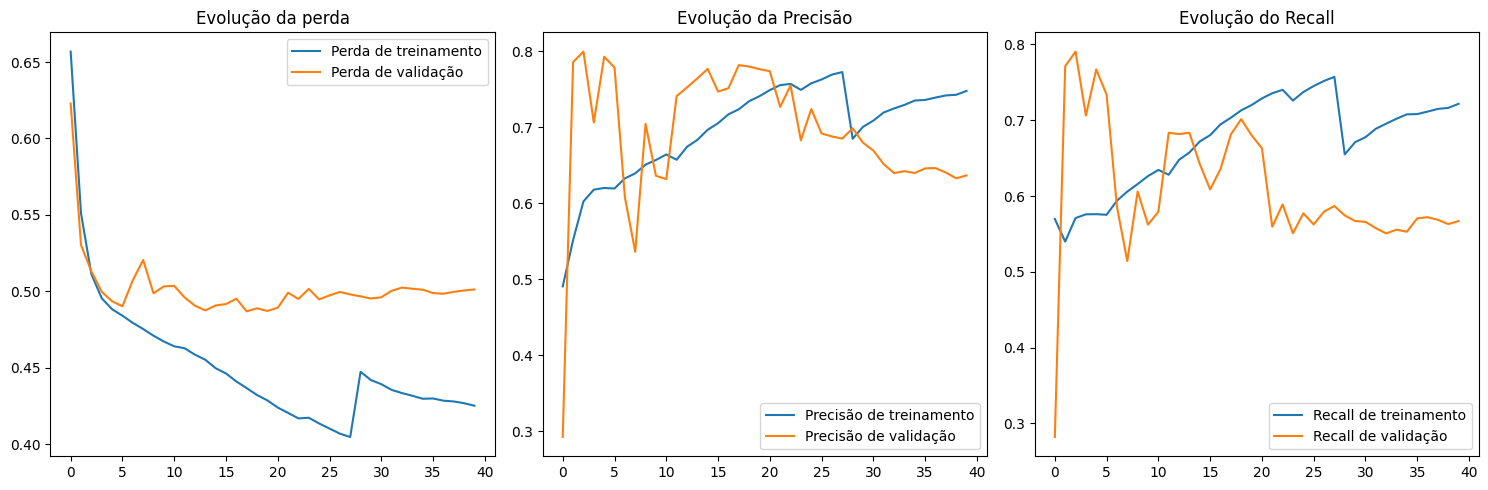

In [18]:
# Visualização da evolução do treinamento
import matplotlib.pyplot as plt

def plot_training_metrics(history_1, history_2):
    print("Chaves disponíveis em history_1:", list(history_1.history.keys()))
    print("Chaves disponíveis em history_2:", list(history_2.history.keys()))

    combined_history = {
        'loss': history_1.history['loss'] + history_2.history['loss'],
        'val_loss': history_1.history['val_loss'] + history_2.history['val_loss'],
        'accuracy': history_1.history['accuracy'] + history_2.history['accuracy'],
        'val_accuracy': history_1.history['val_accuracy'] + history_2.history['val_accuracy'],
        # Usando os nomes corretos das métricas para cada histórico
        'precision': history_1.history['precision'] + history_2.history['precision_1'],
        'val_precision': history_1.history['val_precision'] + history_2.history['val_precision_1'],
        'recall': history_1.history['recall'] + history_2.history['recall_1'],
        'val_recall': history_1.history['val_recall'] + history_2.history['val_recall_1'],
    }

    plt.figure(figsize=(15, 5))
    
    # Perda
    plt.subplot(1, 3, 1)
    plt.plot(combined_history['loss'], label='Perda de treinamento')
    plt.plot(combined_history['val_loss'], label='Perda de validação')
    plt.title('Evolução da perda')
    plt.legend()

    # Precisão
    plt.subplot(1, 3, 2)
    plt.plot(combined_history['accuracy'], label='Precisão de treinamento')
    plt.plot(combined_history['val_accuracy'], label='Precisão de validação')
    plt.title('Evolução da Precisão')
    plt.legend()

    # Recall
    plt.subplot(1, 3, 3)
    plt.plot(combined_history['recall'], label='Recall de treinamento')
    plt.plot(combined_history['val_recall'], label='Recall de validação')
    plt.title('Evolução do Recall')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_metrics(history_1, history_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


2025-04-15 22:53:44.694838: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 301989888 bytes after encountering the first element of size 301989888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1061334..1.0076954].


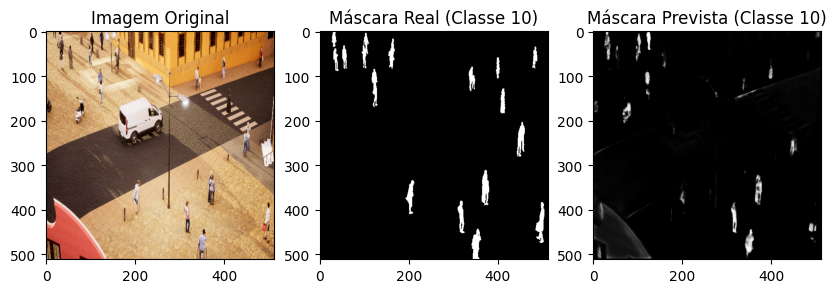

In [16]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagem original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagem Original")

        # Ver classe 0 real e prevista
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 10], cmap='gray')
        plt.title("Máscara Real (Classe 10)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 10], cmap='gray')
        plt.title("Máscara Prevista (Classe 10)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)

In [7]:
# Carregar o modelo salvo com as métricas customizadas
model = tf.keras.models.load_model(
    'best_model_bce_dice_v3.keras',
    custom_objects={
            'loss_function': loss_function,
            'MulticlassIoU': MultilabelIoU
        }
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


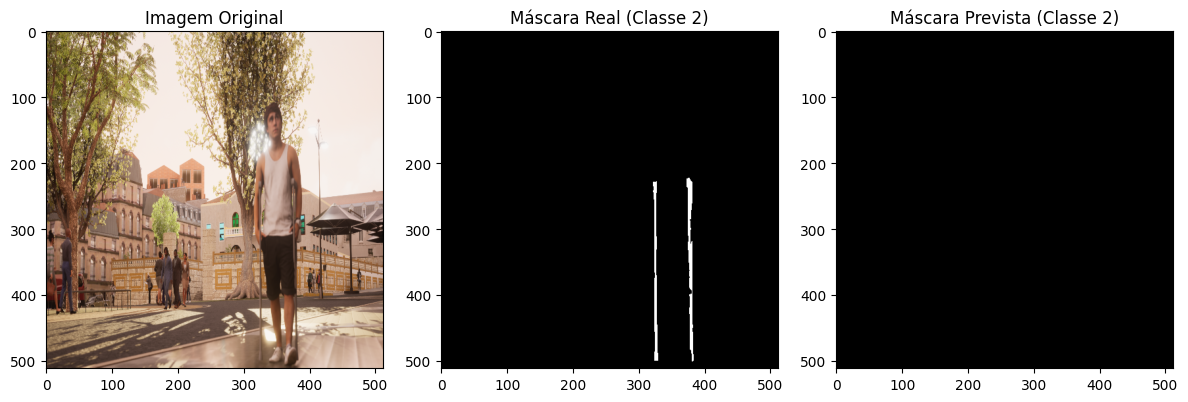


=== Imagem 3116 - Estatísticas ===
Classe 2:
  Pixels positivos (real): 2436.0
  Pixels positivos (previsto): 0


In [29]:
def visualize_multiple_classes(model, dataset, index=212, classes=[10]):
    """
    Mostra a mesma cena com diferentes classes
    """
    count = 0
    for img_batch, mask_batch in dataset:
        batch_size = img_batch.shape[0]
        
        for i in range(batch_size):
            if count == index:
                img = img_batch[i]
                mask = mask_batch[i]
                
                pred_mask = model.predict(tf.expand_dims(img, axis=0))[0]
                binary_pred_mask = (pred_mask >= 0.7).astype(int)

                # Criar figura com múltiplas classes
                num_classes = len(classes)
                fig, axes = plt.subplots(num_classes, 3, figsize=(12, 4*num_classes))
                
                # Garantir que axes seja sempre 2D
                if num_classes == 1:
                    axes = axes.reshape(1, -1)
                
                for row, class_id in enumerate(classes):
                    # Imagem original
                    axes[row, 0].imshow(img.numpy())
                    axes[row, 0].set_title(f"Imagem Original")
                    # axes[row, 0].axis('off')
                    
                    # Máscara real
                    axes[row, 1].imshow(mask[:, :, class_id], cmap='gray')
                    axes[row, 1].set_title(f"Máscara Real (Classe {class_id})")
                    # axes[row, 1].axis('off')
                    
                    # Máscara prevista
                    axes[row, 2].imshow(binary_pred_mask[:, :, class_id], cmap='gray')
                    axes[row, 2].set_title(f"Máscara Prevista (Classe {class_id})")
                    # axes[row, 2].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                print(f"\n=== Imagem {index} - Estatísticas ===")
                for class_id in classes:
                    print(f"Classe {class_id}:")
                    print(f"  Pixels positivos (real): {mask[:, :, class_id].numpy().sum()}")
                    print(f"  Pixels positivos (previsto): {binary_pred_mask[:, :, class_id].sum()}")
                
                return
            
            count += 1
    
    print(f"Aviso: Índice {index} não encontrado no dataset!")

# Ver a cadeira motorizada (imagem 212)
visualize_multiple_classes(model, train_dataset, index=3116, classes=[2])

# Ou ver múltiplas classes da mesma cena
# visualize_multiple_classes(model, train_dataset, index=212, classes=[0, 1, 10, 15])